In [1]:
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
import pandas as pd
import numpy as np


from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.ligsaf_settings import feed_parameters, prices, price_data
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.rcf_oil_purification import create_rcf_oil_purification_system
from lignin_saf.systems.monomer_purification import create_monomer_purification_system
from lignin_saf.systems.hdo import create_hdo_system
from lignin_saf.systems.cellulosic_ethanol_no_preatreatment import create_cellulosic_ethanol_system
from atj_saf.atj_bst.etj_ligfirst import create_etj_system_no_facilities
from lignin_saf.cellulosic_tea import create_cellulosic_ethanol_tea

from lignin_saf.ligsaf_units import HydrogenStorageTank




chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 541.7   # 2016 USD basis

# Poplar group must be defined before creating any stream that references it
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

# ── Area 200: RCF process ──────────────────────────────────────────────────
rcf_system = create_rcf_system(ins=poplar_in)
rcf_system.simulate()

# ── Area 300: Purification ─────────────────────────────────────────────────
rcf_oil_purification_sys = create_rcf_oil_purification_system(ins=F.RCF_CRUDE_OUT)
monomer_purification_sys = create_monomer_purification_system(ins=F.PURE_OIL_OUT)
rcf_oil_purification_sys.simulate()
monomer_purification_sys.simulate()

# ── Area 400: Hydrodeoxygenation ───────────────────────────────────────────
hdo_system = create_hdo_system(ins=F.MON_MONOMERS_OUT)
hdo_system.simulate()

etoh_system = create_cellulosic_ethanol_system(ins=F.Carbohydrate_Pulp, add_denaturant=False)
etoh_system.simulate()

# No pretreatment_wastewater — only S401 stillage filtrate goes to WWT.
etoh_ww     = [F.unit.S401.outs[1]]
etoh_solids = [F.unit.S401.outs[0]]

# Removing the NH3 fraction of the ethanol output - in the future CBP will remove this anyways, so I've just modelled it as a splitter
nh3_splitter = bst.units.Splitter(ins = F.T703.outs[0], split = {'NH3':1.0} )
nh3_splitter.simulate()

# Ethanol to Jet system
etj_system = create_etj_system_no_facilities(ins = nh3_splitter.outs[1])
etj_system.simulate()


WWT = bst.create_conventional_wastewater_treatment_system('WWT', ins=[F.WW_10, F.WastePulp, F.RCF_WW_OUTS, F.WW_11, F.WW_12, F.HDO_WW, F.HDO_wash_water, F.ETJ_WW_OUTS] + etoh_ww)

for unit in WWT.units:
    if hasattr(unit, 'strict_moisture_content'):
        unit.strict_moisture_content = False

F.unit.PWC.ins[0] = WWT.outs[2]

solids_to_BT = bst.Mixer('MIX_BT_solids', ins=[WWT.outs[1]] + etoh_solids)


BT = bst.facilities.BoilerTurbogenerator('BT', fuel_price=prices['CH4'])


gas_mixer= bst.Mixer('MIX_BT_gas', ins=(WWT.outs[0], F.RCF_PSAWASTE_OUTS, F.HDO_purge_gases, F.ETJ_PSAWASTE_OUTS))

BT.ins[0] = solids_to_BT.outs[0]  # Connecting sludge to BT solids feed
BT.ins[1] = gas_mixer.outs[0]   # Connecting biogas from WW treatment and PSA waste gases from RCF


combined_saf = bst.units.Mixer(ins = (F.ETJ_SAF_OUT, F.HDO_CYCLOALKANES_OUT), outs = 'TOTAL_SAF', rigorous = True)

h2_rcf = bst.Stream()
h2_rcf.copy_like(F.RCF_H2_IN)

h2_hdo = bst.Stream()
h2_hdo.copy_like(F.HDO_H2_IN)

h2_etj = bst.Stream()
h2_etj.copy_like(F.ETJ_H2_IN)

# Shared H2 storage — sized from combined ETJ + HDO fresh H2 demand
h2_feed_mixer = bst.Mixer('H2_FEED_MIX', ins=(h2_rcf, h2_hdo, h2_etj))
shared_h2_storage = HydrogenStorageTank('H2_TK', ins=h2_feed_mixer.outs[0])


rcf_pure_mon_hdo_etoh_etj_system = bst.System(
    'RCF+HDO+Cellulosic_ETJ',
    path=(rcf_system, rcf_oil_purification_sys, monomer_purification_sys, hdo_system, etoh_system, etj_system, combined_saf, WWT),
    facilities=[solids_to_BT, gas_mixer, h2_feed_mixer, shared_h2_storage, BT],
)

rcf_pure_mon_hdo_etoh_etj_system.simulate()

F.ETJ_H2_IN.price = price_data['hydrogen']   # 8.46 USD/kg
F.ETJ_RN_OUT.price = price_data['renewable_naphtha']   # 0.71 USD/kg
F.ETJ_RD_OUT.price = price_data['renewable_diesel']    # 1.888 USD/kg





integrated_tea = create_cellulosic_ethanol_tea(rcf_pure_mon_hdo_etoh_etj_system)
mjsp = round(((integrated_tea.solve_price(F.TOTAL_SAF)*F.TOTAL_SAF.rho)/264.172),2)

print(f'The MSP for SAF blend is  {mjsp} USD/gal')



c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Hydrogen has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Methane has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\dew_point.py:129: RuntimeWarning: Methane has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.45e+03 hp), head (3.36e+03 ft), kinematic viscosity (5.99e-07 m2/s), and NPSH (4.21 ft); assuming centrigugal pump
  warn(f'{repr(

The MSP for SAF blend is  30.58 USD/gal


c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:1241: CostWarning: <IsentropicCompressor: RCF_COMP1> power (1.487e-11 hp) is out of bounds (10 to 750 hp) for cost correlation
  self._cost(**cost_kwargs) if cost_kwargs else self._cost()
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:986: RuntimeWarning: the purchase cost item, 'Total Cost', has no defined bare-module factor in the 'HydrogenStorageTank.F_BM' dictionary; bare-module factor now has a default value of 1
  warn(f"the purchase cost item, '{name}', has "


In [2]:
import pandas as pd

for u in rcf_pure_mon_hdo_etoh_etj_system.cost_units:
    print(f"{u.ID}: {round(u.purchase_cost/1e6,2)} MM USD")

ETJ_PUMP1: 0.01 MM USD
RCF_COL2: 1.73 MM USD
RCF_PUMP1: 0.81 MM USD
HDO_FLSH1: 0.11 MM USD
ETJ_RXR2: 1.55 MM USD
RCF_HX1: 0.32 MM USD
HDO_COL2: 0.09 MM USD
ETJ_CAT_MIX: 0.0 MM USD
RCF_PSA1: 1.29 MM USD
RCF_RXR1: 7.04 MM USD
RCF_HX3: 0.01 MM USD
ETJ_HX4: 0.36 MM USD
CT: 0.62 MM USD
CWP: 1.27 MM USD
R302: 0.44 MM USD
BT: 80.74 MM USD
ETJ_HX6: 0.0 MM USD
ETJ_FLSH2: 0.02 MM USD
RCF_PUMP2: 3.7 MM USD
ETJ_HX1: 0.04 MM USD
ETJ_RXR3: 0.4 MM USD
FLASH201: 0.07 MM USD
P403: 0.0 MM USD
ETJ_HX2: 0.6 MM USD
CIP: 0.47 MM USD
RCF_HX2: 0.03 MM USD
ETJ_COL3: 0.16 MM USD
H402: 0.02 MM USD
HDO_COMP_H2: 0.61 MM USD
S401: 3.58 MM USD
ETJ_RXR1: 9.56 MM USD
T302: 0.92 MM USD
ADP: 0.04 MM USD
ETJ_HX5: 0.03 MM USD
ETJ_COMP2: 0.41 MM USD
U401: 2.59 MM USD
T301: 0.61 MM USD
ETJ_COL2: 0.16 MM USD
H403: 0.04 MM USD
R303: 14.24 MM USD
FWT: 0.57 MM USD
HX202: 0.03 MM USD
HDO_FLSH2: 0.03 MM USD
ETJ_FLSH1: 0.05 MM USD
T701: 0.15 MM USD
P701: 0.0 MM USD
CENT203: 0.2 MM USD
HDO_COL1: 1.41 MM USD
RCF_COL1: 3.9 MM USD
LLE

In [3]:
# import pandas as pd
# 
# purchase_df = pd.DataFrame({
#     'Unit': [u.ID for u in rcf_pure_mon_hdo_etoh_etj_system.cost_units],                          # The system here is named my_sys
#     'Purchase Cost': [u.purchase_cost for u in rcf_pure_mon_hdo_etoh_etj_system.cost_units]
# })
# purchase_df.to_excel('equipment_purchase_costs.xlsx', index=False)

In [4]:

F.RCF_RXR2.results()

Hydrogenolysis reactor                               Units  RCF_RXR2
High pressure steam Duty                             kJ/hr  1.85e+07
                    Flow                           kmol/hr       575
                    Cost                            USD/hr       182
Design              Diameter                            ft        14
                    Length                              ft        42
                    Reactor volume                      m3       183
                    Total volume                        m3  1.65e+03
                    Residence time                      hr     0.333
                    Number of reactors                             9
                    Vessel type                             Vertical
                    Weight                              lb   6.6e+05
                    Wall thickness                      in      6.96
                    Duty                             kJ/hr  1.57e+07
                    Catalyst loading cost              USD  1.04e+05
Purchase cost       Vertical pressure vessel (x9)      USD  1.62e+07
                    Platform and ladders (x9)          USD  3.49e+05
Total purchase cost                                    USD  1.66e+07
Utility cost                                        USD/hr       182

In [5]:
import thermosteam as tmo
# Code just to increase the number of display units for the various components
tmo.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
tmo.MultiStream.display_units.N = 40  
bst.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
bst.MultiStream.display_units.N = 40  

In [6]:
F.RCF_RXR2

HydrogenolysisReactor: RCF_RXR2
ins...
[0] Solvolysis_Liquor  from  SolvolysisReactor-RCF_RXR1
    phases: ('g', 'l'), T: 498.15 K, P: 6.3e+06 Pa
    flow (kmol/hr): (g) Water          0.488
                        AceticAcid     3.56e-06
                        CO             83.8
                        Methanol       29.8
                        Hydrogen       9.16e-09
                        Methane        51.7
                    (l) Water          578
                        AceticAcid     48.6
                        Extract        7.4
                        SolubleLignin  87.9
                        Glucan         23.8
                        Xylan          5.92
                        Arabinan       0.757
                        Mannan         9.51
                        Galactan       3.6
                        Methanol       2e+04
                        Hydrogen       3.18e-19
                        Methane        0.00083
[1] s5  from  HXutility-RCF_HX2
    phases: ('g

In [7]:
# Different sections

rcf = [F.MIX100, F.RCF_PUMP1, F.RCF_HX1, F.RCF_RXR1, F.RCF_MIX2, F.RCF_HX2, F.RCF_RXR2, F.RCF_FLSH1, F.RCF_COMP1,
F.RCF_FLSH2, F.RCF_HX3, F.RCF_PSA1, F.RCF_PUMP2, F.RCF_COL1, F.RCF_COL2, F.RCF_MIX3, F.RCF_HX4, F.RCF_FLSH3, F.RCF_MIX4, F.RCF_FLSH4]

oil = [F.MIX200, F.LLE200, F.FLASH201, F.HX202, F.CENT203]

monomer = [F.MIX300, F.LLE300, F.FLASH301, F.HX302, F.CENT303]

hdo = [F.HDO_MIX1, F.HDO_MIX2, F.HDO_MIX3, F.HDO_COMP1, F.HDO_HX1, F.HDO_RXR1, F.HDO_HX2, F.HDO_V1, F.HDO_FLSH1,  F.HDO_FLSH2, F.HDO_HX3, F.HDO_PSA1, F.HDO_COMP_H2, F.HDO_COL1, F.HDO_HX_DOD, F.HDO_COL2,
       F.HDO_HX4, F.HDO_TK1]

etoh = [F.M301, F.H301, F.R301, F.DAP_storage, F.S301, F.CSL_storage, F.S302, F.R303, F.R302, F.T301, F.M304, F.D401, F.M401, F.T302, F.P401, F.H401, F.D402, F.P401, F.D403, F.H402, F.U401, F.H403, 
        F.T701, F.P701, F.T702, F.P702, F.M701, F.T703, F.P403, F.M1, F.S401 ]


etj = [F.ETJ_MIX1, F.ETJ_PUMP1, F.ETJ_HX1, F.ETJ_MIX2, F.ETJ_HX2, F.ETJ_RXR1, F.ETJ_SPLIT1, F.ETJ_FLSH1, F.ETJ_COMP1, F.ETJ_COL1, F.ETJ_COMP2, F.ETJ_COL2, F.ETJ_HX3, F.ETJ_MIX3, F.ETJ_RXR2, 
        F.ETJ_SPLIT2,  F.ETJ_MIX4,  F.ETJ_HX4, F.ETJ_RXR3, F.ETJ_HX5, F.ETJ_FLSH2, F.ETJ_SPLIT3, F.ETJ_COL3, F.ETJ_COL4, F.ETJ_HX6, F.ETJ_HX7, F.ETJ_HX8, F.ETJ_TK1, F.ETJ_TK2, F.ETJ_TK3, F.ETJ_WW_MIX, 
        F.ETJ_CAT_MIX]

other_utilities = [F.CWP, F.CT, F.FWT, F.ADP, F.PWC]

BT = [BT]

WWT = [WWT]

In [8]:
F.HDO_TK1

HydrocarbonProductTank: HDO_TK1
ins...
[0] s47  from  HXutility-HDO_HX4
    phases: ('g', 'l'), T: 288.15 K, P: 101325 Pa
     flow: 0
outs...
[0] HDO_CYCLOALKANES_OUT  to  Mixer-M3
    phases: ('g', 'l'), T: 288.15 K, P: 101325 Pa
     flow: 0


In [9]:
rcf_area_ic = sum(u.installed_cost for u in rcf)
rcf_oil_purification_ic = sum(u.installed_cost for u in oil)
rcf_monomer_purification_ic = sum(u.installed_cost for u in monomer)
etoh_ic =  sum(u.installed_cost for u in etoh)
etj_ic = sum(u.installed_cost for u in etj)
hdo_ic = sum(u.installed_cost for u in hdo)
BT_installed_cost = F.BT.installed_cost
WWT_installed_cost  = F.WWTC.installed_cost
other_utilities_ic = sum(u.installed_cost for u in other_utilities)
h2_storage_ic = F.H2_TK.installed_cost
installed_costs_arr = np.array([rcf_area_ic, rcf_oil_purification_ic, rcf_monomer_purification_ic, hdo_ic, etoh_ic, etj_ic, other_utilities_ic,
                            BT_installed_cost, WWT_installed_cost, h2_storage_ic])


In [10]:
rcf_pure_mon_hdo_etoh_etj_system.installed_cost

989442407.7266115

In [11]:
np.sum(installed_costs_arr)

988607706.5956205

Font: Arial


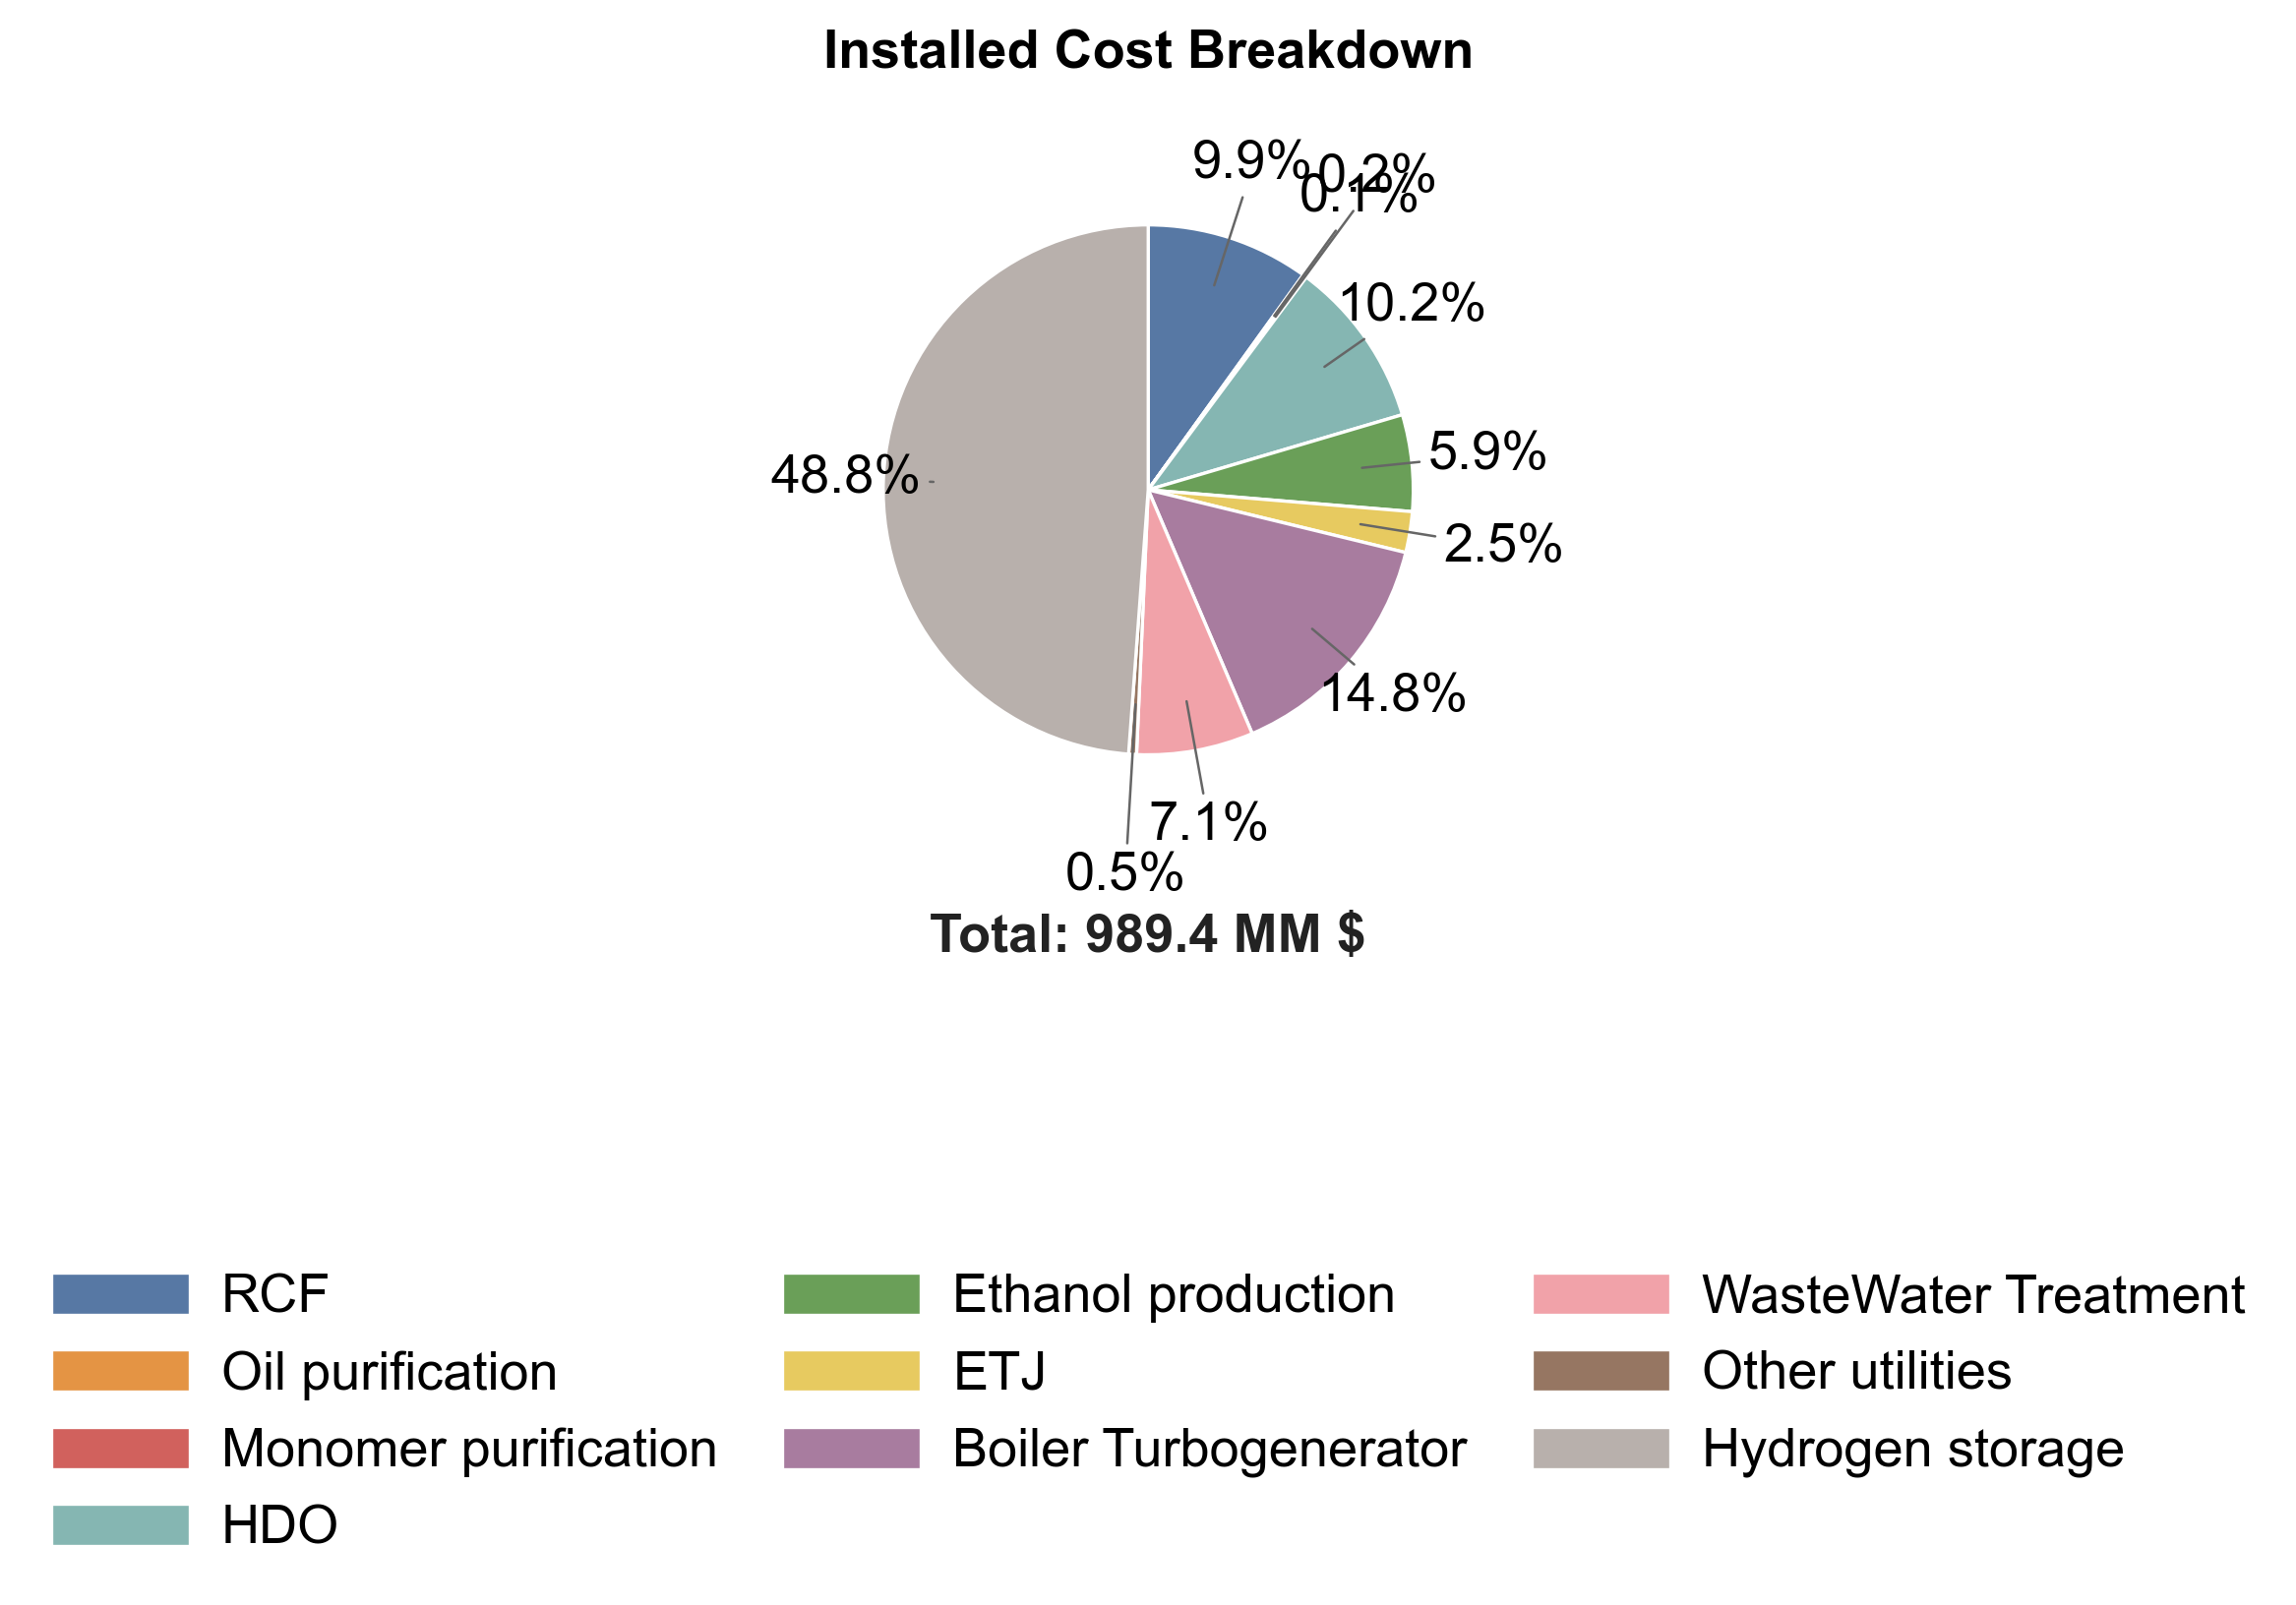

In [16]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Font ──────────────────────────────────────────────────────────────────────
font_pref = ["Arial", "Liberation Sans", "DejaVu Sans"]
available = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
chosen = next((f for f in font_pref if f in available), "DejaVu Sans")
print(f"Font: {chosen}")

plt.rcParams.update({
    "font.family": chosen,
    "mathtext.fontset": "custom",
    "mathtext.rm": chosen,
    "mathtext.it": chosen,
    "mathtext.bf": chosen,
})

plt.rcParams['svg.fonttype'] = 'none'


# Tableu 10 color scheme from https://gist.github.com/leblancfg/b145a966108be05b4a387789c4f9f474
oi_colors = [
  '#5778a4',#blue
  '#e49444',# orange
  '#d1615d', # red
  '#85b6b2', # teal
  '#6a9f58', # green
  '#e7ca60', # yellow
  '#a87c9f', # purple
  '#f1a2a9', # pink
  '#967662', # brown
  '#b8b0ac', # grey,
  "#8D86C9"   # Soft periwinkle - outside color from Tableu 10
]

categories = [
    "RCF",
    "Oil purification",
    "Monomer purification",
    "HDO",
    "Ethanol production",
    "ETJ",
    "Boiler Turbogenerator",
    "WasteWater Treatment",
    "Other utilities",
    "Hydrogen storage"
]

values = [
    rcf_area_ic,
    rcf_oil_purification_ic,
    rcf_monomer_purification_ic,
    hdo_ic,
    etoh_ic,
    etj_ic,
    BT_installed_cost,
    WWT_installed_cost,
    other_utilities_ic,
    h2_storage_ic
]

# ── Figure ────────────────────────────────────────────────────────────────────
DPI      = 300
fig_w_px = 1500
fig_h_px = 1260
fig_w_in = fig_w_px / DPI
fig_h_in = fig_h_px / DPI

FS_TITLE  = 13
FS_TOTAL  = 13
FS_PCT    = 13
FS_LEGEND = 13

fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in))

# ── draw_pie ──────────────────────────────────────────────────────────────────
def draw_pie(ax, vals, title):
    total = sum(vals)
    total_kt = total / 1e6
    fracs = [v / total for v in vals]

    wedges, _ = ax.pie(
        vals,
        colors=oi_colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(linewidth=0.8, edgecolor="white"),
    )

    label_data = []
    for i, (wedge, frac) in enumerate(zip(wedges, fracs)):
        pct   = frac * 100
        theta = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        if pct >= 20:   r_out = 1.14
        elif pct >= 10: r_out = 1.21
        elif pct >= 5:  r_out = 1.29
        else:           r_out = 1.38
        label_data.append(dict(theta=theta, pct=pct, r_out=r_out, r_in=0.78, idx=i))

    small_indices = [d["idx"] for d in label_data if d["pct"] < 5]
    for j, idx in enumerate(small_indices):
        label_data[idx]["r_out"] = 1.36 if j % 2 == 0 else 1.46

    for d in label_data:
        theta, r_in, r_out, pct = d["theta"], d["r_in"], d["r_out"], d["pct"]
        ax.annotate(
            f"{pct:.1f}%",
            xy=(r_in  * np.cos(theta), r_in  * np.sin(theta)),
            xytext=(r_out * np.cos(theta), r_out * np.sin(theta)),
            fontsize=FS_PCT,
            ha="center", va="center",
            arrowprops=dict(
                arrowstyle="-", color="#666666", lw=0.6,
                shrinkA=0, shrinkB=2,
            ),
        )

    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=6)
    ax.text(0, -1.6,
            r"Total: " + f"{rcf_pure_mon_hdo_etoh_etj_system.installed_cost/1e6:.1f}" + r" MM $",
            ha="center", va="top", fontsize=FS_TOTAL,
            color="#222222", fontweight="bold", style="normal")

    ax.set_xlim(-1.65, 1.65)
    ax.set_ylim(-1.95, 1.50)

draw_pie(ax, values, "Installed Cost Breakdown")

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(facecolor=c, edgecolor="white", linewidth=0.8, label=lbl)
    for c, lbl in zip(oi_colors, categories)
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,
    fontsize=FS_LEGEND,
    frameon=False,
    columnspacing=1.2,
    handlelength=2.6,
    handleheight=0.85,
    handletextpad=0.6,
    bbox_to_anchor=(0.5, 0.0),
)

plt.rcParams['svg.fonttype'] = 'none'

fig.tight_layout(rect=[0, 0.14, 1, 1])

#fig.savefig("ghg_pie_chart.png", dpi=DPI, bbox_inches="tight")
fig.savefig("installed_cost_breakdown_2.svg", format="svg", bbox_inches="tight")
#print("Done.")

In [ ]:
F.MIX200.results()

,Mixer,Units,MIX200
Total purchase cost,,USD,0
Utility cost,,USD/hr,NaN
